# EDA (II)
#### Code to plot R, G or B degrees from a single .tif file in a histogram. 

In [8]:
# Import necessary modules
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
from PIL import Image
from os import listdir
from os.path import isfile, join
from itertools import chain
from random import randrange

In [2]:
# Read training labels csv
eda = pd.read_csv('train_labels.csv') #, usecols = ['label']
eda['T_F'] = np.where(eda['label']== 0, 'False', 'True')
eda

,id,label,T_F
0,f38a6374c348f90b587e046aac6079959adf3835,0,False
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1,True
2,755db6279dae599ebb4d39a9123cce439965282d,0,False
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0,False
4,068aba587a4950175d04c680d38943fd488d6a9d,0,False
...,...,...,...
220020,53e9aa9d46e720bf3c6a7528d1fca3ba6e2e49f6,0,False
220021,d4b854fe38b07fe2831ad73892b3cec877689576,1,True
220022,3d046cead1a2a5cbe00b2b4847cfb7ba7cf5fe75,0,False
220023,f129691c13433f66e1e0671ff1fe80944816f5a2,0,False


In [3]:
# List all of the files in the training directory
mypath = '/kaggle/input/histopathologic-cancer-detection/train'
onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f))]

In [4]:
# Put all the file names (excluding the .tiff part) in a new list (onlyfiles_I)
onlyfiles_I = []

for i in range(len(onlyfiles)):

    onlyfiles_I.append(onlyfiles[i][:40])

# Put the file names with and without extensions in a data frame 
id_join = {'id_I' : onlyfiles, 'id_II': onlyfiles_I}
id_join
id_df = pd.DataFrame(id_join)

In [5]:
# Merge with the original EDA dataset so I can select observations based on the label
eda_I = eda.merge(id_df, left_on = 'id', right_on = 'id_II')
eda_I

# A sub sample of only zero labels  
zero_sample = int(len(onlyfiles)*0.1*0.6)
eda_zero = eda_I[eda_I.label == 0]
sample_eda_zero = eda_zero.sample(n = zero_sample, replace=False, random_state=25)

# A sub sample of only one labels  
one_sample = int(len(onlyfiles)*0.1*0.4)
eda_one = eda_I[eda_I.label == 1]
sample_eda_one = eda_one.sample(n = one_sample, replace=False, random_state=25)


In [33]:
# Function which: 
## Puts file names of the sample dataset (label '0') in a list
## Converts image to an array in a RGB format
## For every single file, selects all from one of three of the RGB values
## Puts all of the values (either the value of R, G or the B) in a list.
def sample_RGB_0(color_zero, number): 

    zeroes = list(sample_eda_zero.id_I)

    color_zero = []

    pick = randrange(len(zeroes))

    j = zeroes[pick]

    im = Image.open(mypath + '/' + j )

    imarray = np.array(im)

    color_zero = list(chain.from_iterable(imarray[:,:,number]))

    color_zero.insert(0, j)

    return color_zero

In [35]:
# Function which: 
## Puts file names of the sample dataset (label '1') in a list
## Converts image to an array in a RGB format
## For every single file, selects all from one of three of the RGB values
## Puts all of the values (either the value of R, G or the B) in a list.
def sample_RGB_1(color_one, number): 

    ones = list(sample_eda_one.id_I)

    color_one = []

    pick = randrange(len(ones))

    j = ones[pick]

    im = Image.open(mypath + '/' + j )

    imarray = np.array(im)

    color_one = list(chain.from_iterable(imarray[:,:,number]))

    color_one.insert(0, j)

    return color_one

In [76]:
# Run sample_RGB_0 for R,G and B  
red_zero = sample_RGB_0('color_red', 0)
green_zero = sample_RGB_0('color_green',1)
blue_zero = sample_RGB_0('color_blue',2)

In [77]:
# Run sample_RGB_1 for R,G and B 
red_one = sample_RGB_1('color_red', 0)
green_one = sample_RGB_1('color_green',1)
blue_one = sample_RGB_1('color_blue',2)

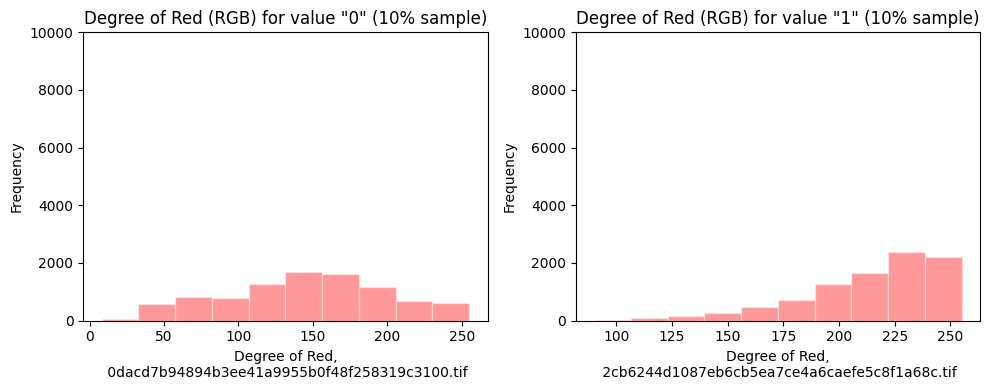

In [78]:
text_r0 = red_zero[0]
text_r1 = red_one[0]

# Histograms for degree of red in sample data sets with labels '0' and '1' 
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(red_zero[1:], color = 'red', edgecolor='white', alpha = 0.4)
ax[0].set_title('Degree of Red (RGB) for value "0" (10% sample)')
ax[0].set_xlabel('Degree of Red,\n {}'.format(text_r0)) # list the exact .tif file
ax[0].set_ylabel('Frequency')
ax[0].set_ylim(0,10000)

ax[1].hist(red_one[1:], color = 'red', edgecolor='white', alpha = 0.4)
ax[1].set_title('Degree of Red (RGB) for value "1" (10% sample)')
ax[1].set_xlabel('Degree of Red,\n {}'.format(text_r1)) # list the exact .tif file
ax[1].set_ylabel('Frequency')
ax[1].set_ylim(0,10000)

fig.tight_layout()
plt.show()

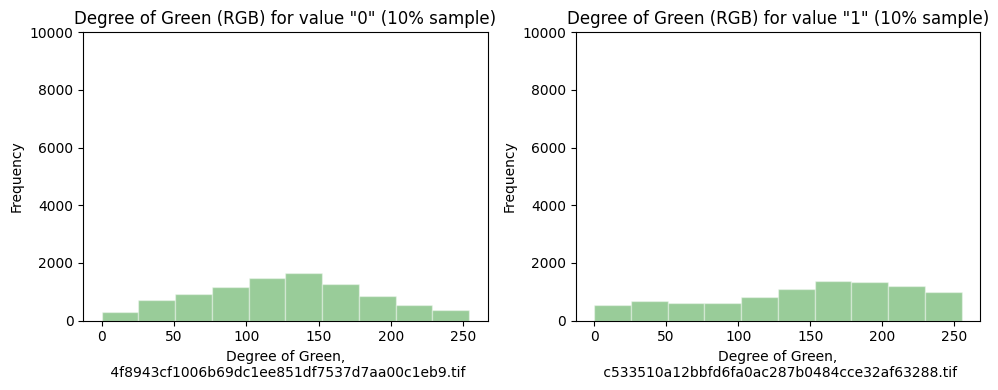

In [79]:
text_g0 = green_zero[0]
text_g1 = green_one[0]

# Histograms for degree of green in sample data sets with labels '0' and '1' 
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(green_zero[1:], color = 'green', edgecolor='white', alpha = 0.4)
ax[0].set_title('Degree of Green (RGB) for value "0" (10% sample)')
ax[0].set_xlabel('Degree of Green,\n {}'.format(text_g0)) # list the exact .tif file
ax[0].set_ylabel('Frequency')
ax[0].set_ylim(0,10000)

ax[1].hist(green_one[1:], color = 'green', edgecolor='white', alpha = 0.4)
ax[1].set_title('Degree of Green (RGB) for value "1" (10% sample)')
ax[1].set_xlabel('Degree of Green,\n {}'.format(text_g1)) # list the exact .tif file
ax[1].set_ylabel('Frequency')
ax[1].set_ylim(0,10000)

fig.tight_layout()
plt.show()

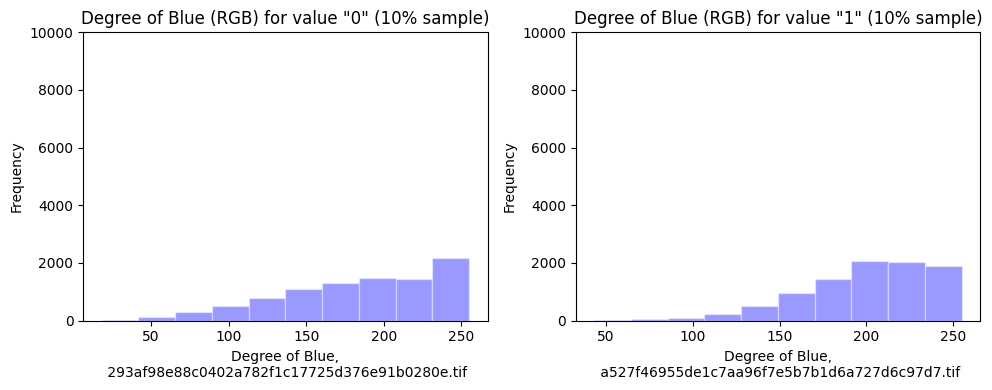

In [80]:
text_b0 = blue_zero[0]
text_b1 = blue_one[0]

# Histograms for degree of blue in sample data sets with labels '0' and '1' 
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(blue_zero[1:], color = 'blue', edgecolor='white', alpha = 0.4)
ax[0].set_title('Degree of Blue (RGB) for value "0" (10% sample)')
ax[0].set_xlabel('Degree of Blue,\n {}'.format(text_b0)) # list the exact .tif file
ax[0].set_ylabel('Frequency')
ax[0].set_ylim(0,10000)

ax[1].hist(blue_one[1:], color = 'blue', edgecolor='white', alpha = 0.4)
ax[1].set_title('Degree of Blue (RGB) for value "1" (10% sample)')
ax[1].set_xlabel('Degree of Blue,\n {}'.format(text_b1)) # list the exact .tif file
ax[1].set_ylabel('Frequency')
ax[1].set_ylim(0,10000)

fig.tight_layout()
plt.show()